# Diamond Price Prediction💎

This project aims to predict diamond prices using various regression models. The dataset includes features such as size and clarity, along with their corresponding prices.

# About Dataset
Dataset source: [Diamonds Price Dataset](https://www.kaggle.com/datasets/amirhosseinmirzaie/diamonds-price-dataset/data)   
  
This dataset represents a range of diamonds with different features:


*   carat: diamond weight in carat.
*   cut: diamond cutting quality.
*   color: diamond color from J (worst) to D (best).
*   clarity: a measure of diamond clarity (from left to right is worst to best: I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF).
*   x: diamond length in mm.
*   y: diamond width in mm.
*   z: diamond depth in mm.
*   depth: percentage depth that is equal to z / mean(x,y).
*   table: the width of the widest point at the top of the diamond.
*   price: diamond price. *(target variable)*

# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")        # Ignore all Python warnings

In [2]:
# Importing essential libraries
import pandas as pd  # Import pandas for data manipulation.
import numpy as np  # Import numpy for numerical operations.
import matplotlib.pyplot as plt  # Import matplotlib's pyplot for plotting.
import seaborn as sns  # Import seaborn for enhanced statistical plots.
import os
import kagglehub

# Importing regression models from scikit-learn and other libraries
from sklearn import metrics  # Importing metrics module for evaluation metrics

# Linear models
from sklearn.linear_model import LinearRegression  # Linear Regression, a basic but widely used regression model.
from sklearn.linear_model import Ridge  # Ridge Regression, a type of linear regression with L2 regularization.
from sklearn import linear_model  # for other linear models.

# Decision Tree and Ensemble models
from sklearn.tree import DecisionTreeRegressor  # Decision Tree
from sklearn.ensemble import RandomForestRegressor  # Random Forest
from sklearn.ensemble import ExtraTreesRegressor  # Extra Trees
from sklearn.ensemble import BaggingRegressor  # Bagging

from sklearn.svm import SVR  # Support Vector Machine
import xgboost as xgb  # Gradient Boosting
from sklearn.neighbors import KNeighborsRegressor  # Nearest Neighbors

# Data Loading

In [3]:
# Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [4]:
# Download the dataset
path = kagglehub.dataset_download("amirhosseinmirzaie/diamonds-price-dataset")
path

100%|██████████| 557k/557k [00:00<00:00, 40.9MB/s]

Extracting files...


'/content/data/datasets/amirhosseinmirzaie/diamonds-price-dataset/versions/1'

In [5]:
# Import dataset
df = pd.read_csv(path+'/diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
# Displaying basic information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    50000 non-null  float64
 1   cut      50000 non-null  object 
 2   color    50000 non-null  object 
 3   clarity  50000 non-null  object 
 4   depth    50000 non-null  float64
 5   table    50000 non-null  float64
 6   price    50000 non-null  int64  
 7   x        50000 non-null  float64
 8   y        50000 non-null  float64
 9   z        50000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.8+ MB


In [7]:
# Obtaining the size of the DataFrame
df.shape

(50000, 10)

In [8]:
df.describe()

,carat,depth,table,price,x,y,z
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.799444,61.753006,57.457830,3944.805440,5.734403,5.737956,3.541056
std,0.475173,1.431088,2.232092,3997.938105,1.123077,1.145579,0.707065
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
df.duplicated().sum()

np.int64(126)

In [10]:
df[df.duplicated(keep=False)].head(20)

,carat,cut,color,clarity,depth,table,price,x,y,z
917,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
918,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
919,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
920,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
921,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1870,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
1871,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
2021,1.00,Fair,E,SI2,67.0,53.0,3136,6.19,6.13,4.13
2022,1.00,Fair,E,SI2,67.0,53.0,3136,6.19,6.13,4.13
2610,1.00,Fair,F,SI2,65.1,55.0,3265,6.26,6.23,4.07


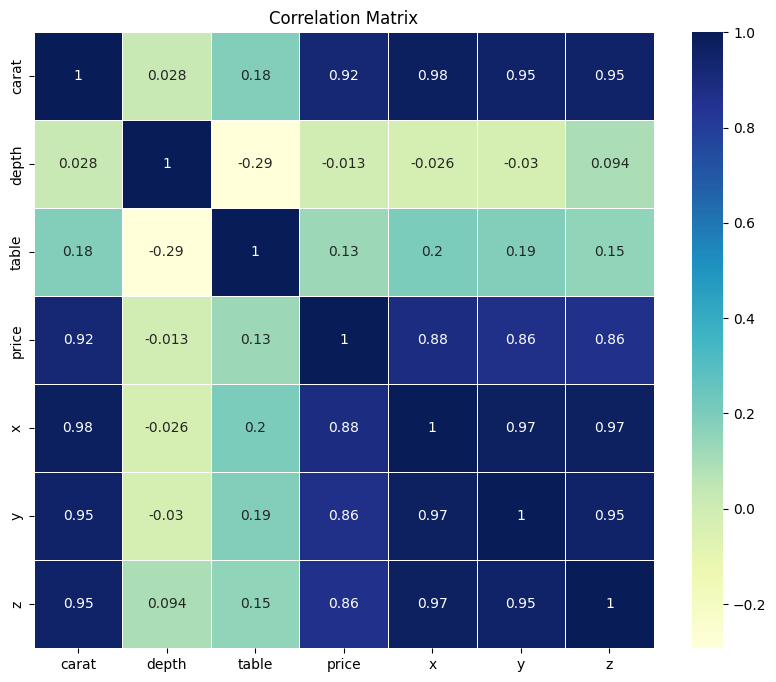

In [11]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame

# Selecting numeric columns and calculating the correlation matrix
numeric_df = df.select_dtypes(include='number')  # Filter the DataFrame to keep only numeric columns
correlation_matrix = numeric_df.corr()  # Calculate the correlation matrix

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()


This table shows the correlation matrix for the numeric features:
- **carat**, **x**, **y**, and **z** are strongly positively correlated with **price** (greater than 0.86), meaning that an increase in any of these features is associated with an increase in price.

- **depth** is negatively correlated with **price** (-0.013), meaning that an increase in depth slightly decreases the price, but the effect is minimal.

- **table** has a weak positive correlation with **price** (0.13), meaning that a larger table may be associated with a slight increase in price, but the impact is not strong.

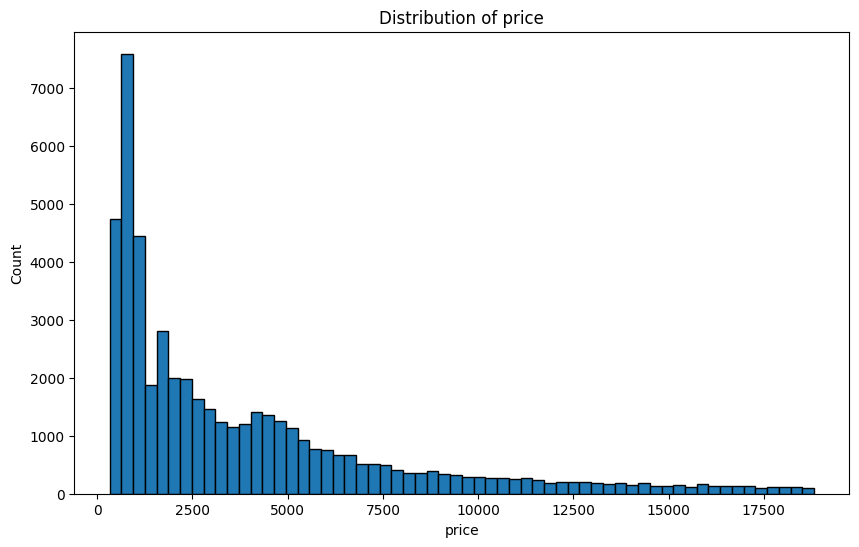

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=60, edgecolor='black')
plt.title('Distribution of price')
plt.xlabel('price')
plt.ylabel('Count')
plt.show()

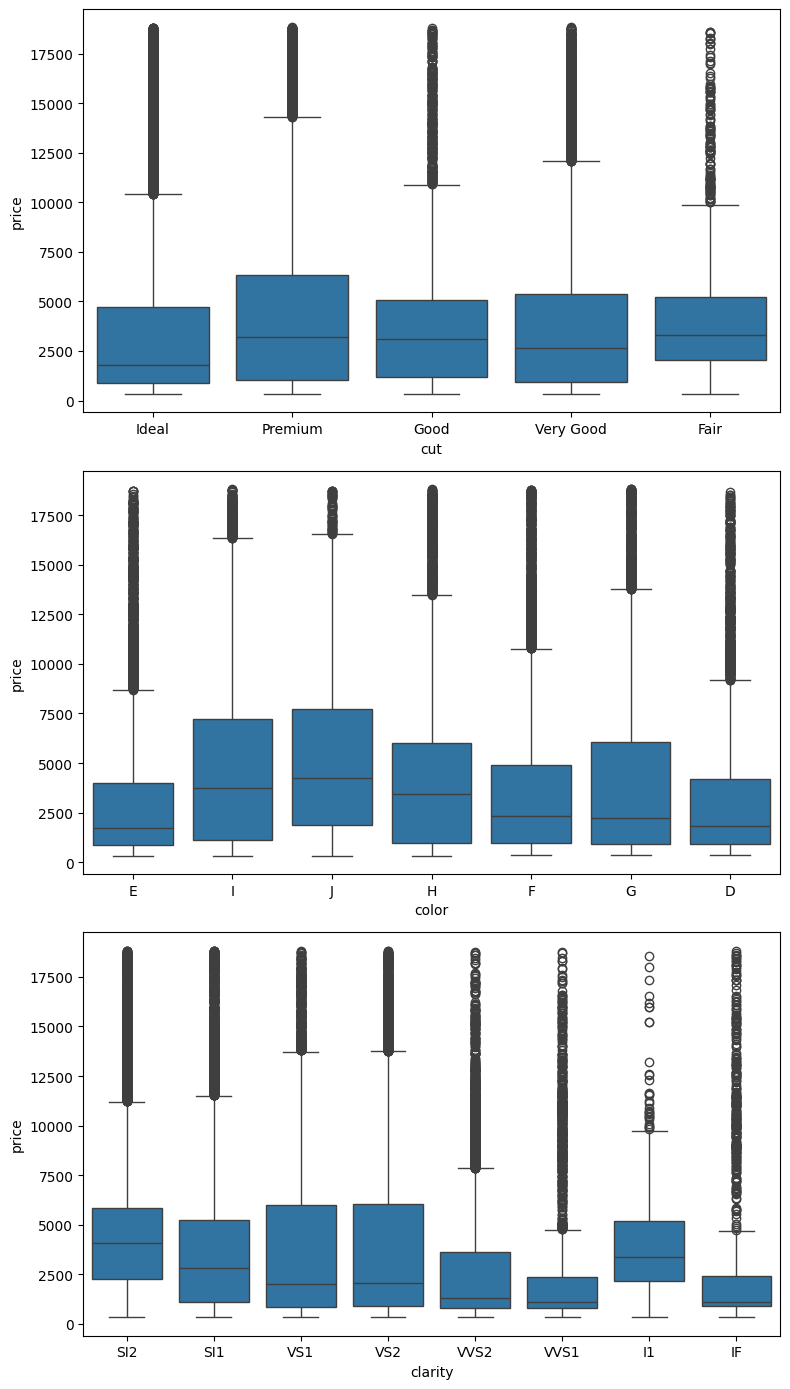

In [13]:
plt.figure(figsize=(8, 14))
plt.subplot(3,1,1)
sns.boxplot(x = 'cut', y = 'price', data = df)
plt.subplot(3,1,2)
sns.boxplot(x = 'color', y = 'price', data = df)
plt.subplot(3,1,3)
sns.boxplot(x = 'clarity', y = 'price', data = df)
plt.tight_layout()
plt.show()

*   I need to convert three object columns into numerical values to perform machine learning.
*   I found 126 duplicated rows that need to be dropped.
*   The minimum values of x, y, and z are 0, indicating missing values that I will drop.

# Data Preparation







In [14]:
df_c = df.copy()

In [15]:
# 1. Removing rows with zero values
def drop_rows_with_zero(dataset, col):
    index = dataset[dataset[col] == 0].index
    return dataset.drop(index, inplace=False)

df_c = drop_rows_with_zero(df_c, 'x')
df_c = drop_rows_with_zero(df_c, 'z')
df_c.describe()

,carat,depth,table,price,x,y,z
count,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000,49983.000000
mean,0.799214,61.753088,57.457566,3943.076086,5.734869,5.738302,3.542260
std,0.474970,1.430864,2.231614,3995.956857,1.120889,1.143739,0.704162
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2409.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5347.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [16]:
# 2. Drop duplicated samples
df_c.drop_duplicates(keep='first',inplace=True)
df_c.duplicated().sum()

np.int64(0)

In [17]:
#3. Feature encoding for categorical variables
print(f"cut : {df_c['cut'].unique()}")
print(f"color : {df_c['color'].unique()}")
print(f"clarity : {df_c['clarity'].unique()}")

cut : ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
color : ['E' 'I' 'J' 'H' 'F' 'G' 'D']
clarity : ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [18]:
df_c.replace({"Ideal":1, "Premium":2, "Very Good":3, "Good":4, "Fair":5}, inplace=True)
df_c.replace({"D":1, "E":2, "F":3, "G":4, "H":5, "I":6, "J":7}, inplace=True)
df_c.replace({"IF":1, "VVS1":2, "VVS2":3, "VS1":4, "VS2":5, "SI1":6, "SI2":7, "I1": 8}, inplace=True)

print(f"cut : {df_c['cut'].unique()}")
print(f"color : {df_c['color'].unique()}")
print(f"clarity : {df_c['clarity'].unique()}")

cut : [1 2 4 3 5]
color : [2 6 7 5 3 4 1]
clarity : [7 6 4 5 3 2 8 1]


In [19]:
# Splitting the DataFrame into independent and dependent variables
X = df_c.drop(['price'], axis=1)
y = df_c['price']

X.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,1,2,7,61.5,55.0,3.95,3.98,2.43
1,0.21,2,2,6,59.8,61.0,3.89,3.84,2.31
2,0.23,4,2,4,56.9,65.0,4.05,4.07,2.31
3,0.29,2,6,5,62.4,58.0,4.20,4.23,2.63
4,0.31,4,7,7,63.3,58.0,4.34,4.35,2.75


In [20]:
y.head()

,price
0,326
1,326
2,327
3,334
4,335


# Train and Evaluate the Models

In [21]:
# Importing train_test_split function
from sklearn.model_selection import train_test_split  # Imports the train_test_split function, which is used to randomly split the data into training and testing sets.

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Getting the shapes of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((34899, 9), (14958, 9), (34899,), (14958,))

In [22]:
# Importing MinMaxScaler
from sklearn.preprocessing import MinMaxScaler  # Imports the MinMaxScaler, which is used to scale features to a given range, typically 0 to 1.

# Initializing the MinMaxScaler with a feature range of 0 to 1
mmscaler = MinMaxScaler(feature_range=(0, 1))  # Creates an instance of MinMaxScaler, setting the feature range to scale between 0 and 1.

# Scaling the training data
X_train = mmscaler.fit_transform(X_train)

# Scaling the testing data
X_test = mmscaler.transform(X_test)

# Converting scaled arrays back to DataFrame format
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [23]:
# Initializing an empty dictionary for storing model results
a = {'Model Name': [], 'Mean_Absolute_Error_MAE': [], 'Adj_R_Square': [], 'Root_Mean_Squared_Error_RMSE': [],
     'Mean_Absolute_Percentage_Error_MAPE': [], 'Mean_Squared_Error_MSE': [], 'Root_Mean_Squared_Log_Error_RMSLE': [],
     'R2_score': []}

# Creating a DataFrame from the dictionary
Results = pd.DataFrame(a)

# Displaying the first few rows of the DataFrame
Results.head()

,Model Name,Mean_Absolute_Error_MAE,Adj_R_Square,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score


In [24]:
# Create objects of Regression / Regressor models with default hyper-parameters

modelmlg = LinearRegression()
modeldcr = DecisionTreeRegressor()
modelbag = BaggingRegressor()
modelrfr = RandomForestRegressor()
modelSVR = SVR()
modelXGR = xgb.XGBRegressor()
modelKNN = KNeighborsRegressor(n_neighbors=5)
modelETR = ExtraTreesRegressor()
modelRE = Ridge()
modelLO = linear_model.Lasso(alpha=0.1)

In [25]:
# Evalution matrix for all the algorithms

MM = [modelmlg, modeldcr, modelrfr, modelKNN, modelETR, modelXGR, modelbag,modelRE,modelLO]

# Assuming that you have already initialized the `Results` DataFrame as shown previously

for models in MM:
    models.fit(X_train, y_train)
    y_pred = models.predict(X_test)

    # Evaluation metrics
    mae = round(metrics.mean_absolute_error(y_test, y_pred), 3)
    mse = round(metrics.mean_squared_error(y_test, y_pred), 3)
    rmse = round(np.sqrt(mse), 3)
    r2 = round(metrics.r2_score(y_test, y_pred), 6)
    rmsle = round(np.log(rmse), 3)

    def MAPE(y_test, y_pred):
        y_test, y_pred = np.array(y_test), np.array(y_pred)
        return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    result_mape = MAPE(y_test, y_pred)

    r_squared = r2
    adjusted_r_squared = round(1 - (1-r_squared)*(len(y)-1)/(len(y)-X.shape[1]-1), 6)

    # Create a dictionary for the new row
    new_row = {'Model Name': type(models).__name__, 'Mean_Absolute_Error_MAE': mae,
               'Adj_R_Square': adjusted_r_squared, 'Root_Mean_Squared_Error_RMSE': rmse,
               'Mean_Absolute_Percentage_Error_MAPE': result_mape,
               'Mean_Squared_Error_MSE': mse, 'Root_Mean_Squared_Log_Error_RMSLE': rmsle,
               'R2_score': r2}

    # Append new row to Results DataFrame using pd.concat
    Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)

    print('------------------------------------------------------------------------------------------------------------')


------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------


In [26]:
Results

,Model Name,Mean_Absolute_Error_MAE,Adj_R_Square,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score
0,LinearRegression,801.563,0.896148,1267.422,44.013674,1606359.473,7.145,0.896167
1,DecisionTreeRegressor,362.623,0.965694,728.451,8.748084,530640.971,6.591,0.965700
2,RandomForestRegressor,267.403,0.981655,532.693,6.527236,283762.049,6.278,0.981658
3,KNeighborsRegressor,346.452,0.969383,688.161,9.485213,473564.892,6.534,0.969389
4,ExtraTreesRegressor,264.309,0.981905,529.045,6.531650,279888.280,6.271,0.981908
5,XGBRegressor,273.815,0.981835,530.075,7.159262,280979.312,6.273,0.981838
6,BaggingRegressor,282.655,0.979490,563.237,6.909033,317236.409,6.334,0.979494
7,Ridge,812.111,0.901926,1231.661,44.957192,1516988.040,7.116,0.901944
8,Lasso,801.944,0.900412,1241.130,44.088891,1540404.180,7.124,0.900430


In [27]:
# Define the list of model names
models = ['LinearRegression', 'DecisionTreeRegressor', 'RandomForestRegressor', 'KNeighborsRegressor',
          'ExtraTreesRegressor', 'XGBRegressor', 'BaggingRegressor', 'Ridge Regression', 'Lasso Regression']

# Create a DataFrame to store the model names and corresponding metrics
result = pd.DataFrame({'Model_Name': models})  # Initialize the DataFrame with model names

# Assign the evaluation metrics from the Results DataFrame to the new DataFrame
result['Adj_R_Square'] = Results['Adj_R_Square']  # Add Adjusted R-Squared values
result['Mean_Absolute_Error_MAE'] = Results['Mean_Absolute_Error_MAE']  # Add Mean Absolute Error values
result['Root_Mean_Squared_Error_RMSE'] = Results['Root_Mean_Squared_Error_RMSE']  # Add Root Mean Squared Error values
result['Mean_Absolute_Percentage_Error_MAPE'] = Results['Mean_Absolute_Percentage_Error_MAPE']  # Add Mean Absolute Percentage Error values
result['Mean_Squared_Error_MSE'] = Results['Mean_Squared_Error_MSE']  # Add Mean Squared Error values
result['Root_Mean_Squared_Log_Error_RMSLE'] = Results['Root_Mean_Squared_Log_Error_RMSLE']  # Add Root Mean Squared Log Error values
result['R2_score'] = Results['R2_score']  # Add R-Squared values

# Sort the DataFrame by Adjusted R-Squared in descending order and reset the index
result = result.sort_values(by='Adj_R_Square', ascending=False).reset_index(drop=True)

# Display the result DataFrame
result


,Model_Name,Adj_R_Square,Mean_Absolute_Error_MAE,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score
0,ExtraTreesRegressor,0.981905,264.309,529.045,6.531650,279888.280,6.271,0.981908
1,XGBRegressor,0.981835,273.815,530.075,7.159262,280979.312,6.273,0.981838
2,RandomForestRegressor,0.981655,267.403,532.693,6.527236,283762.049,6.278,0.981658
3,BaggingRegressor,0.979490,282.655,563.237,6.909033,317236.409,6.334,0.979494
4,KNeighborsRegressor,0.969383,346.452,688.161,9.485213,473564.892,6.534,0.969389
5,DecisionTreeRegressor,0.965694,362.623,728.451,8.748084,530640.971,6.591,0.965700
6,Ridge Regression,0.901926,812.111,1231.661,44.957192,1516988.040,7.116,0.901944
7,Lasso Regression,0.900412,801.944,1241.130,44.088891,1540404.180,7.124,0.900430
8,LinearRegression,0.896148,801.563,1267.422,44.013674,1606359.473,7.145,0.896167


<p> From the Above Results, The Top 3 Models by comparing Errors , Adj_R_Square and R2_Score values are<br>
    
1. **ExtraTreesRegressor**
2. **XGBRegressor**
3. **RandomForestRegressor**

Training the Data with **ExtraTreesRegressor**

In [28]:
# Training the model
modelETR.fit(X_train, y_train)  # Fit the Extra Trees Regressor model to the training data

# Predicting with the model on test data
y_pred = modelETR.predict(X_test)

In [29]:
# Creating a DataFrame to compare actual and predicted prices
out = pd.DataFrame({'Price_actual': y_test, 'Price_pred': y_pred})

# Merging the comparison DataFrame with the original backup DataFrame
result = df_c.merge(out, left_index=True, right_index=True)
result.sample(10)

,carat,cut,color,clarity,depth,table,price,x,y,z,Price_actual,Price_pred
46818,0.75,2,3,7,60.9,58.0,2274,5.88,5.91,3.59,2274,2379.18
18631,1.20,3,4,4,63.4,56.0,8596,6.74,6.70,4.26,8596,7456.54
29297,0.35,3,2,5,58.9,59.0,767,4.59,4.64,2.72,767,738.37
8266,1.01,4,2,7,58.5,61.0,4506,6.51,6.55,3.82,4506,4418.66
28741,0.37,3,3,5,61.0,58.0,746,4.61,4.63,2.82,746,769.90
35742,0.60,5,2,7,66.5,56.0,1033,5.31,5.21,3.50,1033,1283.44
21517,1.71,2,4,7,62.6,57.0,11227,7.66,7.60,4.78,11227,9793.11
29401,0.36,2,3,6,61.9,59.0,770,4.54,4.51,2.80,770,738.36
33735,0.45,2,6,6,62.2,58.0,941,4.89,4.86,3.03,941,876.94
28189,0.33,1,5,2,61.6,55.0,730,4.45,4.48,2.75,730,745.49


# Result Visualization

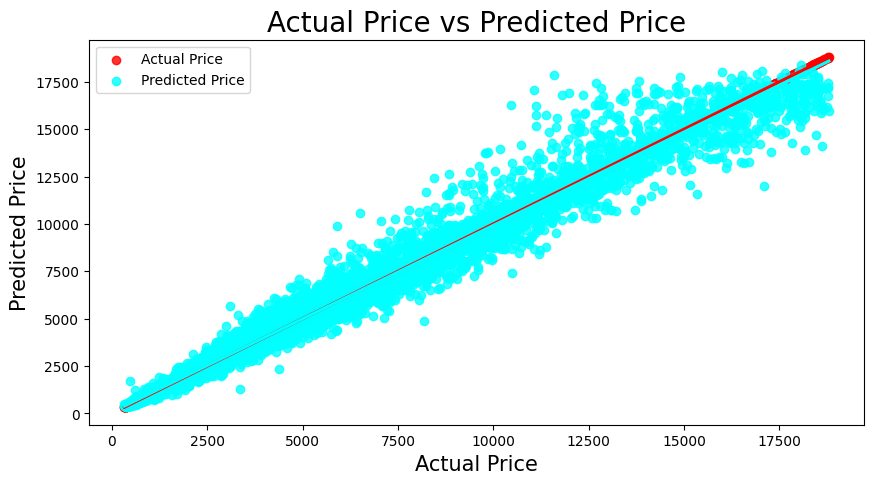

In [30]:
# Setting up the plot area
plt.figure(figsize=(10, 5))

# Creating a regression plot for actual prices
sns.regplot(x='Price_actual', y='Price_actual', data=result, color='Red', label='Actual Price')  # Plot actual prices with blue color.

# Creating a regression plot for predicted prices
sns.regplot(x='Price_actual', y='Price_pred', data=result, color='cyan', label='Predicted Price')  # Plot predicted prices with cyan color.

# Adding plot title and labels
plt.title('Actual Price vs Predicted Price', fontsize=20)
plt.xlabel('Actual Price', fontsize=15)
plt.ylabel('Predicted Price', fontsize=15)

# Adding legend to differentiate between actual and predicted prices
plt.legend()

# Displaying the plot
plt.show()

# Thank you🙏
Raghad Alzahrani.